<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **K-Nearest Neighbors**


KNN is a simple but effective model that can be used for both classification and regression tasks. When the feature space is not too large, KNN can be highly interpretable because each prediction can be explained by examining the nearest training examples that influenced the result.
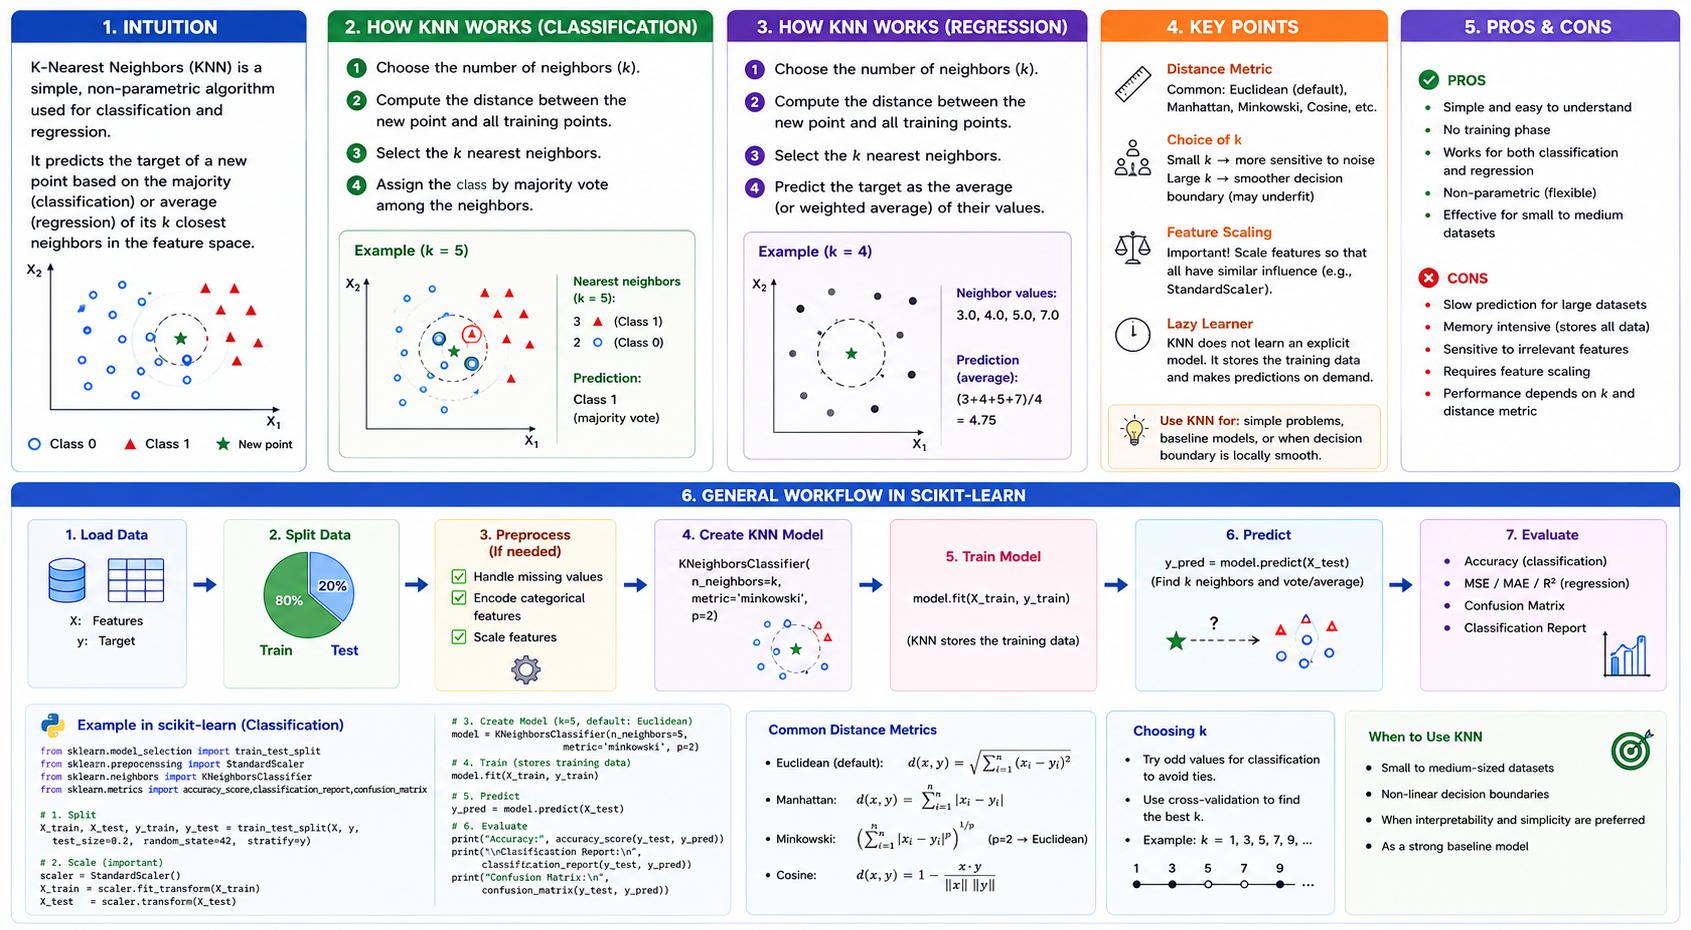


## **Introduction**

KNN classifies a new sample by comparing it with the training samples and finding the `K` closest neighbors. The closeness is usually calculated with a distance metric, such as Euclidean distance:

$$
d(x, y) = \sqrt{(x_1 - y_1)^2 + (x_2 - y_2)^2 + \cdots + (x_n - y_n)^2}
$$

KNN does **not** have a training cost or loss function like linear regression or logistic regression. It does not learn coefficients by minimizing a loss. Instead, it stores the training data and uses distance during prediction.

After calculating the distances, KNN selects the `K` nearest neighbors and predicts the class that appears most often among them:

$$
\hat{y} = \operatorname{mode}(y_1, y_2, \ldots, y_K)
$$

Here, $y_1, y_2, \ldots, y_K$ are the class labels of the `K` nearest neighbors, and `mode` means the most common class.

For example, if `K = 5` and 3 of the 5 nearest neighbors are benign while 2 are cancerous, the model predicts the sample as benign.

So for KNN, the main calculation is distance plus majority vote, not loss minimization.


## **Objectives**


We will use a tumor sample dataset that contains lab test results. The objective is to classify each tumor as benign or malignant. This is a binary classification task because the target has two possible classes.

* Train KNN models with different values of `n_neighbors`
* Evaluate KNN models for a classification task
* Tune the number of neighbors and choose the best value for this dataset


----


## **Workflow**


### **Setup**


In [74]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn import metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [75]:
# Define a random seed for reproducible results
rs = 123

In [76]:
# Ignore deprecation warnings
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 

### **Load and explore the dataset**


First, load the `tumor.csv` dataset as a Pandas DataFrame:


In [77]:
# Read the dataset from a CSV file
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/datasets/tumor.csv"
tumor_df = pd.read_csv(dataset_url)

Next, look at the first few rows of the DataFrame.


In [78]:
tumor_df.head()

,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,5,1,1,1,2,1,3,1,1,0
1,5,4,4,5,7,10,3,2,1,0
2,3,1,1,1,2,2,3,1,1,0
3,6,8,8,1,3,4,3,7,1,0
4,4,1,1,3,2,1,3,1,1,0


Now display the column names.


In [79]:
tumor_df.columns

Index(['Clump', 'UnifSize', 'UnifShape', 'MargAdh', 'SingEpiSize', 'BareNuc',
       'BlandChrom', 'NormNucl', 'Mit', 'Class'],
      dtype='object')

Each row in this dataset represents one tumor sample. The feature columns contain lab test results, such as clump thickness and cell shape. The target variable is `Class`, where the goal is to predict whether the tumor is benign or malignant.


Next, split the dataset into input features `X` and target variable `y`:


In [80]:
X = tumor_df.iloc[:, :-1]
y = tumor_df.iloc[:, -1:]

Now check the summary statistics for the input features in `X`:


In [81]:
X.describe()

,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit
count,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221
std,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


The feature values are all numeric and range from 1 to 10. Because the features are already on the same scale, we do not need to apply feature scaling for this lab.


Next, check the class distribution of the target variable `y`:


In [82]:
y.value_counts(normalize=True)

Class
0        0.650073
1        0.349927
Name: proportion, dtype: float64

<Axes: xlabel='Class'>

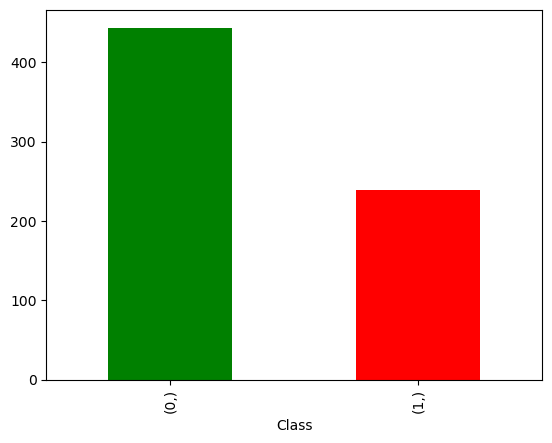

In [83]:
y.value_counts().plot.bar(color=['green', 'red'])

About 65% of the tumors are benign (`Class = 0`) and about 35% are malignant (`Class = 1`). This class distribution is not severely imbalanced.


### **Split training and testing datasets**


In [84]:
# Use 80% of the data for training
# Use 20% of the data for testing
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    stratify=y, random_state = rs)

### **Train and evaluate a KNN classifier**


Training a KNN classifier in `sklearn` is similar to training other classifiers. First, define a `KNeighborsClassifier` object. Here, `n_neighbors=2` means the model uses the 2 closest training samples to make each prediction. The other model settings are left at their default values.


In [85]:
# Define a KNN classifier with `n_neighbors=2`
knn_model = KNeighborsClassifier(n_neighbors=2)

Next, train the model with `X_train` and `y_train`. The `ravel()` method converts `y_train` from a DataFrame into a one-dimensional array.


In [86]:
knn_model.fit(X_train, y_train.values.ravel())

,n_neighbors,2
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Now use the trained model to make predictions on `X_test`.


In [87]:
preds = knn_model.predict(X_test)

To evaluate the KNN classifier, we use a helper function based on `classification_report()`. It returns common classification metrics, including precision, recall, F1-score, support, and accuracy.

In this binary classification dataset, class `0` means benign and class `1` means malignant. `classification_report()` shows metrics for each class, then reports overall accuracy, macro average, and weighted average. This makes it easier to compare model performance for benign and malignant tumors.


In [88]:
print(classification_report(y_test, preds, target_names=['Benign', 'Cancerous']))


              precision    recall  f1-score   support

      Benign       0.94      0.98      0.96        89
   Cancerous       0.95      0.88      0.91        48

    accuracy                           0.94       137
   macro avg       0.95      0.93      0.93       137
weighted avg       0.94      0.94      0.94       137



The classification report shows strong performance on the tumor sample dataset. This means the KNN model can identify malignant tumors effectively in this test set.

Next, try a different number of neighbors to see whether the model performance improves.


### **Coding Exercise:** 
#### **Train and Evaluate a KNN Classifier with 5 Neighbors**


First, define a KNN classifier using the `KNeighborsClassifier` class.

Setting `n_neighbors=5` means the model predicts each tumor sample by finding the 5 closest training samples and choosing the class that appears most often among those neighbors.


In [89]:
# Define a KNN classifier with 5 neighbors
model = KNeighborsClassifier(n_neighbors=5)


Then train the model with `X_train` and `y_train`:


In [90]:
# Train the classifier
model.fit(X_train, y_train.values.ravel())


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Then make predictions on the `X_test` DataFrame:


In [91]:
# Make predictions on the test dataset
preds = model.predict(X_test)


Finally, evaluate the KNN model with `classification_report()` to review precision, recall, and F1-score for each class.


In [92]:
print(classification_report(y_test, preds, target_names=['Benign', 'Cancerous']))


              precision    recall  f1-score   support

      Benign       0.99      0.98      0.98        89
   Cancerous       0.96      0.98      0.97        48

    accuracy                           0.98       137
   macro avg       0.97      0.98      0.98       137
weighted avg       0.98      0.98      0.98       137



**Findings:**

>The KNN model with 5 neighbors performs very well on the test data. It is especially useful that recall for the malignant class is high, because this means the model correctly identifies most malignant tumors in the test set.


#### **Tune the Number of Neighbors to Find the Best K Value**


The value of `n_neighbors` controls how many nearby training samples the model uses for prediction. To find a strong value for this dataset, we can test several `K` values and compare their classification performance.


Here, we test `K` values from 1 to 50 and store the weighted F1-score for each value in a list.


In [93]:
# Test K values from 1 to 50
max_k = 50
# Create an empty list to store the F1-score for each K value
f1_scores = []

Next, train 50 KNN classifiers, one for each `K` value from 1 to 50.


In [94]:
for k in range(1, max_k + 1):
    # Create a KNN classifier
    knn = KNeighborsClassifier(n_neighbors=k)
    # Train the classifier
    knn = knn.fit(X_train, y_train.values.ravel())
    preds = knn.predict(X_test)
    # Evaluate the classifier with the weighted F1-score
    f1 = f1_score(preds, y_test)
    f1_scores.append((k, round(f1_score(y_test, preds), 4)))
# Convert the F1-score list to a DataFrame
f1_results = pd.DataFrame(f1_scores, columns=['K', 'F1 Score'])
f1_results.set_index('K')

,F1 Score
K,
1,0.9485
2,0.9130
3,0.9485
4,0.9583
5,0.9691
6,0.9583
7,0.9583
8,0.9474
9,0.9474


The list of F1-scores is hard to compare directly, so we visualize the scores with a line chart.


Text(0.5, 1.0, 'KNN F1 Score')

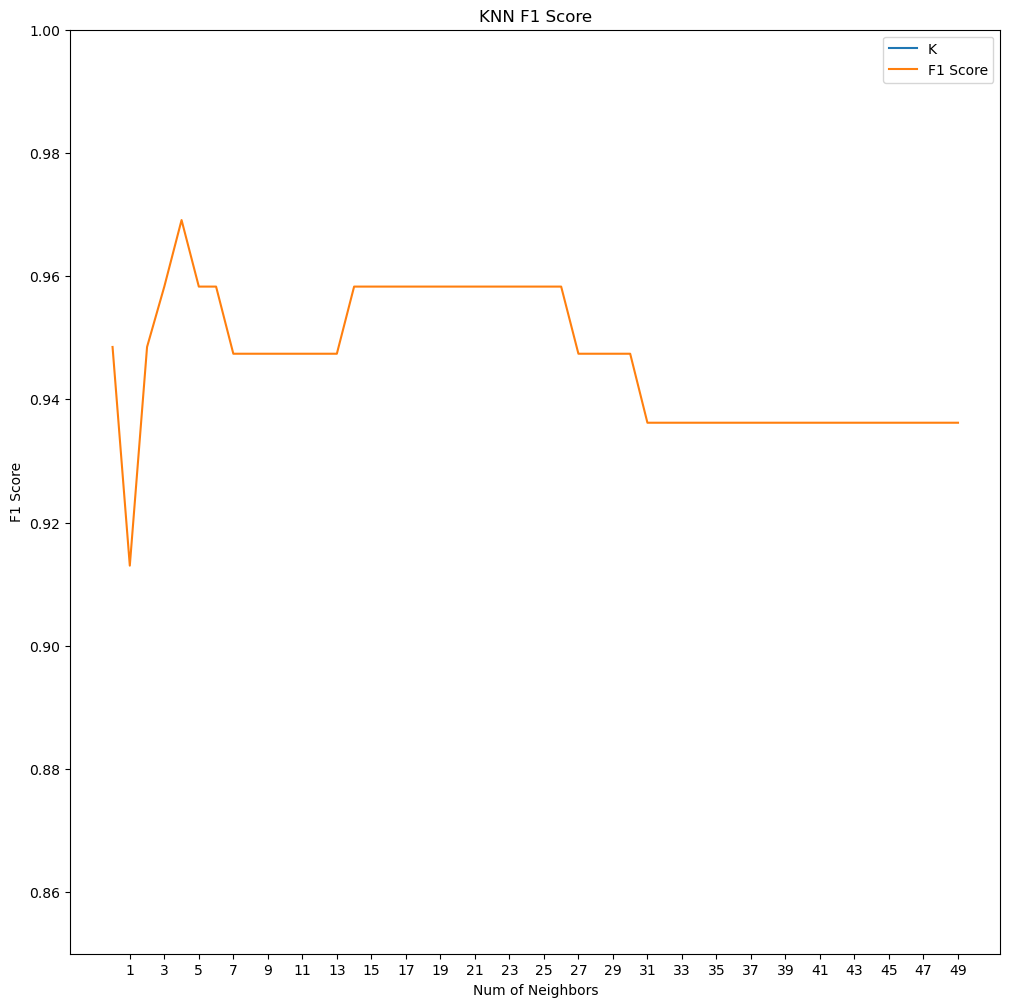

In [95]:
# Plot the F1-score results
ax = f1_results.plot(figsize=(12, 12))
ax.set(xlabel='Num of Neighbors', ylabel='F1 Score')
ax.set_xticks(range(1, max_k, 2));
plt.ylim((0.85, 1))
plt.title('KNN F1 Score')

**Findings:**

>The F1-score line chart shows that the best `K` value is 5, with an F1-score of about `0.9691`. This means the 5-neighbor KNN model gives the strongest overall performance among the tested values.


## **Authors**


[Yan Luo](https://www.linkedin.com/in/yan-luo-96288783/),
Su Wu


Copyright © 2021 IBM Corporation. All rights reserved.
